<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [3]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 137.8 MB/s eta 0:00:00


In [4]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 93.6 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-05-12 05:50:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  38.4MB/s    in 4.0s    

2026-05-12 05:50:36 (38.5 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [6]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [16]:
df.head(20)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



Text(0.5, 1.0, 'job satisfaction by Age')

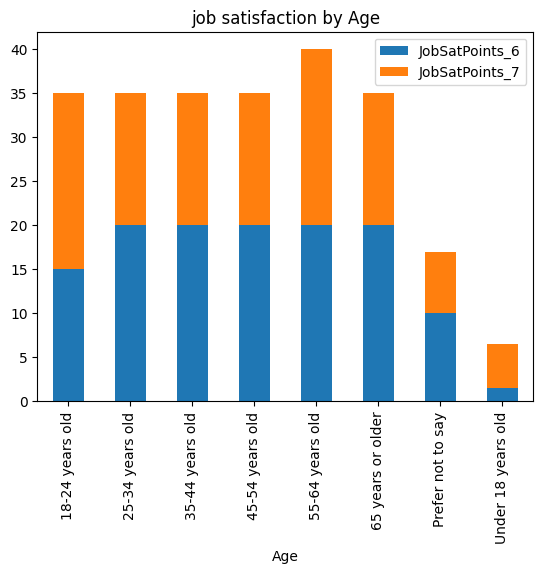

In [37]:
##Write your code here
df[['Age','JobSatPoints_6', 'JobSatPoints_7']].dropna()
df2 =df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
df2.plot.bar(stacked=True,)
plt.title('job satisfaction by Age')



##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


<StringArray>
[                                 'Employed, full-time',
                                   'Student, full-time',
                   'Not employed, but looking for work',
 'Independent contractor, freelancer, or self-employed',
               'Not employed, and not looking for work',
                                   'Student, part-time',
                                  'Employed, part-time',
                                  'I prefer not to say',
                                              'Retired']
Length: 9, dtype: str


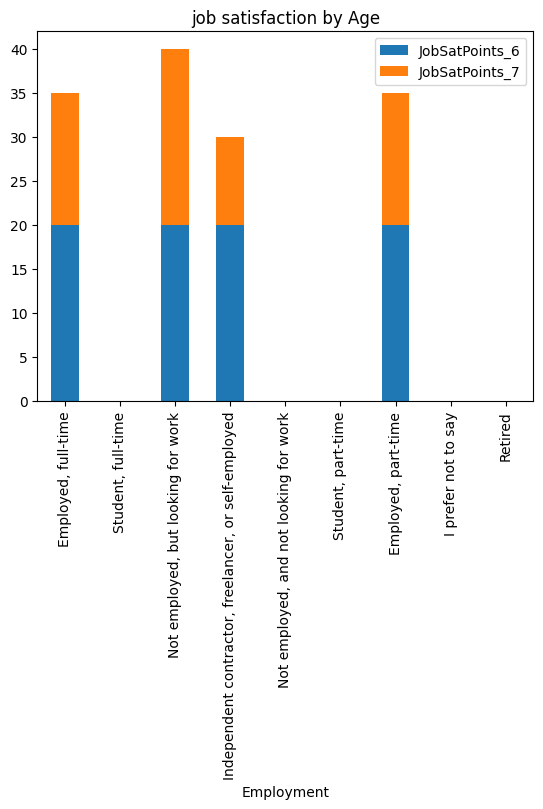

In [63]:
##Write your code here

df[['Employment','JobSatPoints_6', 'JobSatPoints_7']].dropna()

label = df['Employment'].str.split(';').explode().str.strip().unique()
df2 =df.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()
task1_2 = df2.reindex(label)

task1_2.plot.bar(stacked=True,)
plt.title('job satisfaction by Age')


### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


                   Age  ConvertedCompYearly  JobSatPoints_6  CompNorm
389    25-34 years old             110000.0            20.0  0.796062
417    25-34 years old              29000.0             0.0  0.209871
423    25-34 years old              66592.0            30.0  0.481921
428    25-34 years old             230000.0             0.0  1.664493
444    25-34 years old             146496.0            30.0  1.060181
...                ...                  ...             ...       ...
41160  25-34 years old              17945.0             0.0  0.129867
41161  25-34 years old              50000.0            25.0  0.361846
41171  25-34 years old              62296.0             5.0  0.450832
41173  25-34 years old              23256.0            40.0  0.168302
41180  25-34 years old              44640.0             0.0  0.323056

[7431 rows x 4 columns]


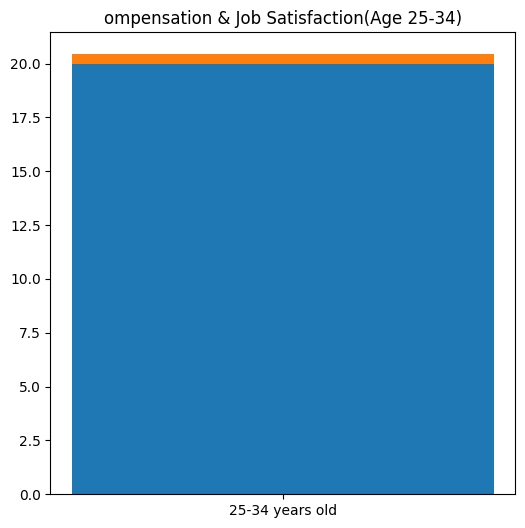

In [22]:
##Write your code here

#filter thedataframe to specific respondders and eliminate null values
dfc =df[['Age','ConvertedCompYearly', 'JobSatPoints_6']].dropna()
dfc = dfc[dfc['Age']=='25-34 years old']
#normalized the Convertedcomp year
dfc['CompNorm']=dfc['ConvertedCompYearly']/dfc['ConvertedCompYearly'].max()*100
#calculate the median of compnormn and jobsat
median_job = dfc['JobSatPoints_6'].median()
median_comp = dfc['CompNorm'].median()

fig, ax=plt.subplots(figsize=(6,6))

ax.bar(['25-34 years old'],median_job)
ax.bar(['25-34 years old'],median_comp,bottom = median_job)
ax.set_title('Compensation & Job Satisfaction(Age 25-34)')
       
print (dfc)


##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


Text(0.5, 1.0, 'compensation and Job satisfaction by Age')

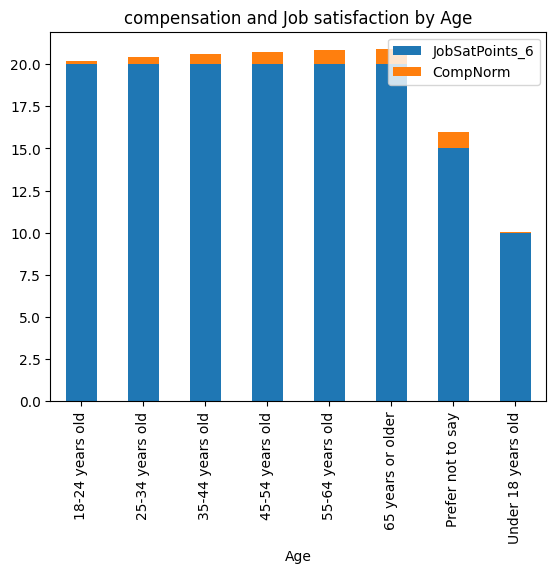

In [23]:
##Write your code here

dfc =df[['Age','ConvertedCompYearly', 'JobSatPoints_6']].dropna()

#normalized the Convertedcomp year
dfc['CompNorm']=dfc['ConvertedCompYearly']/dfc['ConvertedCompYearly'].max()*100
#calculate the median of compnormn and jobsat
dfg= dfc.groupby('Age')[['JobSatPoints_6','CompNorm']].median()

dfg.plot.bar(stacked=True,)
plt.title('compensation and Job satisfaction by Age')


### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


Text(0.5, 1.0, 'Preferred Databases by Age Group')

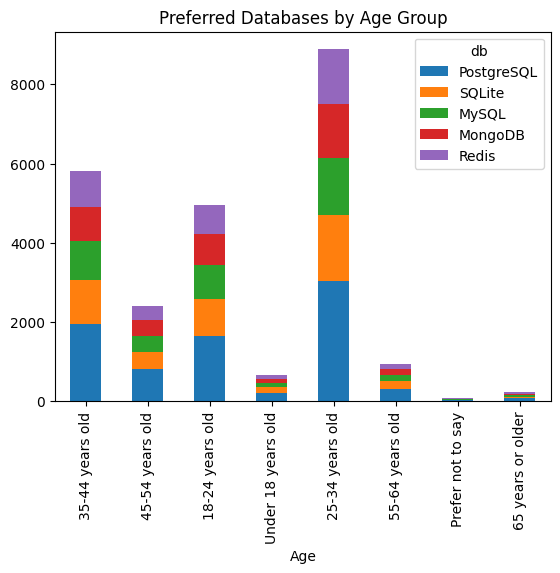

In [42]:
##Write your code here

dfd= df[['DatabaseWantToWorkWith','Age']].dropna()
dfd['db']= dfd['DatabaseWantToWorkWith'].str.split(';').explode('db').str.strip()
ages = dfd['Age'].unique()

top5_db =dfd['db'].value_counts().head(5).index.tolist()
db_fil = dfd[dfd['db'].isin(top5_db)]
dfplot = (db_fil.groupby(['Age','db']).size().unstack(fill_value=0).reindex(ages)[top5_db])
dfplot.plot.bar(stacked=True,)
plt.title('Preferred Databases by Age Group')

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


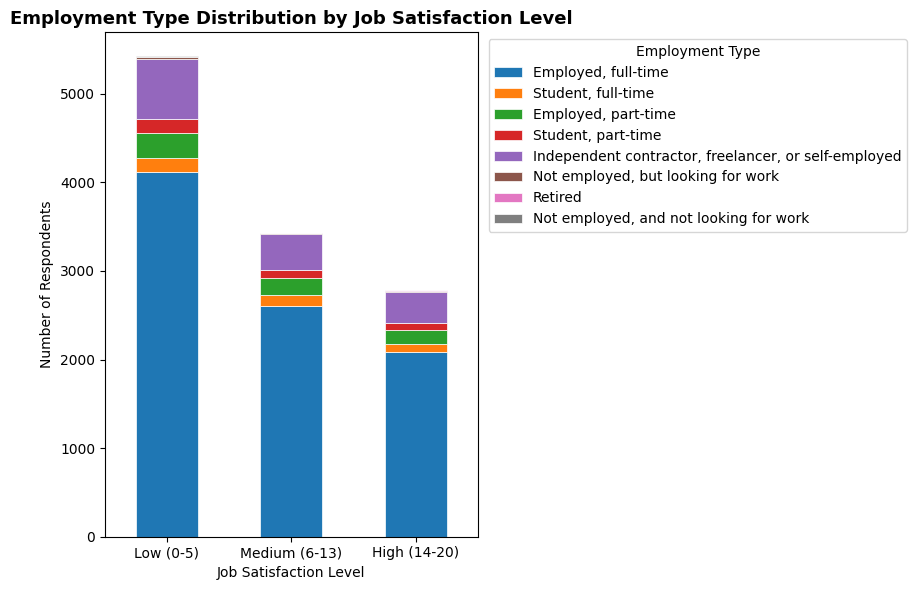

In [66]:
##Write your code here

dfte = df[['Employment','JobSatPoints_6']].dropna()

dfte['SatLevel'] = pd.cut(
    dfte['JobSatPoints_6'],
    bins=[-1, 5, 15, 20],                             
    labels=['Low (0-5)', 'Medium (6-13)', 'High (14-20)']
)
dfte['Employment'] = dfte['Employment'].str.split(';').explode('Employment').str.strip()
emp_order =dfte['Employment'].unique().dropna()
# ── Step 2: Count Employment types within each Satisfaction Level ─────────────
task3_2 = (
    dfte.groupby(['SatLevel', 'Employment'])
    .size()
    .unstack(fill_value=0)
    [emp_order]            # enforce a consistent column order
)


# ── Step 3: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

task3_2.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    edgecolor='white',
    linewidth=0.5
)

ax.set_title('Employment Type Distribution by Job Satisfaction Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Job Satisfaction Level')
ax.set_ylabel('Number of Respondents')
ax.set_xticklabels(['Low (0-5)', 'Medium (6-13)', 'High (14-20)'], rotation=0)
ax.legend(title='Employment Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


lang                JavaScript  Python   SQL  HTML/CSS  TypeScript
Age                                                               
35-44 years old           5161    4239  5055      4580        3766
45-54 years old           2051    1802  2382      1800        1146
18-24 years old           4728    5157  4004      4523        3567
Under 18 years old         919    1105   440      1030         505
25-34 years old           7936    7431  7516      6937        6696
55-64 years old            819     741  1028       715         320
Prefer not to say           85     105    63        97          41
65 years or older          170     194   204       169          38


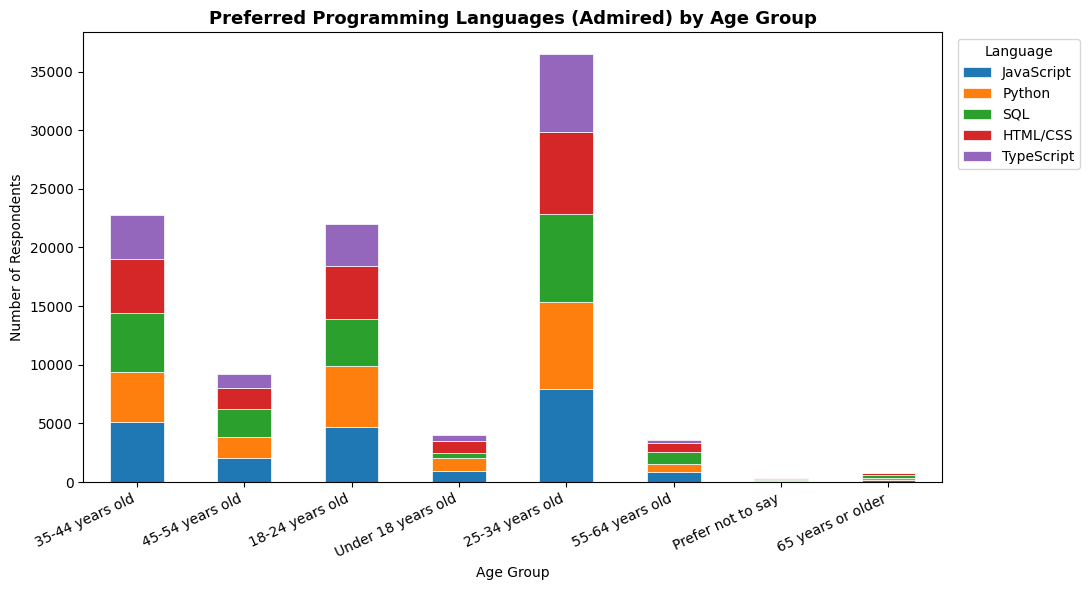

In [69]:
##Write your code here
lang_exp = df[['Age', 'LanguageAdmired']].copy()
lang_exp = lang_exp.assign(
    lang=lang_exp['LanguageAdmired'].str.split(';')
).explode('lang')
lang_exp['lang'] = lang_exp['lang'].str.strip()

# ── Step 2: Top 5 most admired languages ─────────────────────────────────────
top_langs = lang_exp['lang'].value_counts().head(5).index.tolist()
lang_filt  = lang_exp[lang_exp['lang'].isin(top_langs)]

# ── Step 3: Pivot (Age × Language) count table ───────────────────────────────
task4_1 = (
    lang_filt
    .groupby(['Age', 'lang'])
    .size()
    .unstack(fill_value=0)
    .reindex(ages)[top_langs]
)

print(task4_1)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

task4_1.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    edgecolor='white',
    linewidth=0.5
)

ax.set_title('Preferred Programming Languages (Admired) by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Respondents')
ax.set_xticklabels(ages, rotation=25, ha='right')
ax.legend(title='Language', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [ ]:
##Write your code here

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
